In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
s_0 = 100 
mu = 0.10
sigma = 0.20
T = 1
N = 252 * T
dt = T / N
num_paths = 1000
Z = np.random.standard_normal((num_paths, N))

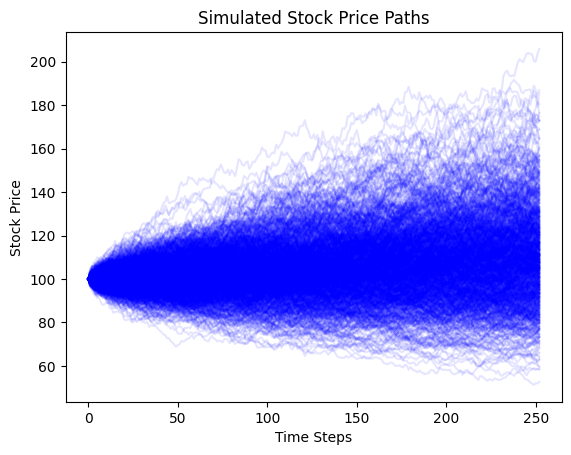

In [3]:
prices = np.zeros ((num_paths, N+1))
prices[:, 0] = s_0         
for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

plt.plot(prices.T, color='blue', alpha=0.1)
plt.title('Simulated Stock Price Paths')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.show()

## Observations and some notes
This GBM simulator started as a single path on Excel before being scaled to 1000 paths in Python. Through experimentation with the parameters, the most important early insight was that **sigma dominates mu** in shaping the simulation. Higher mu shifts the cone upward: a modest directional effect. Higher sigma however drives the spread of outcomes explosively, capturing how volatility governs uncertainty far more than drift does. The scenario grid below makes this contrast visible across 16 parameter combinations.

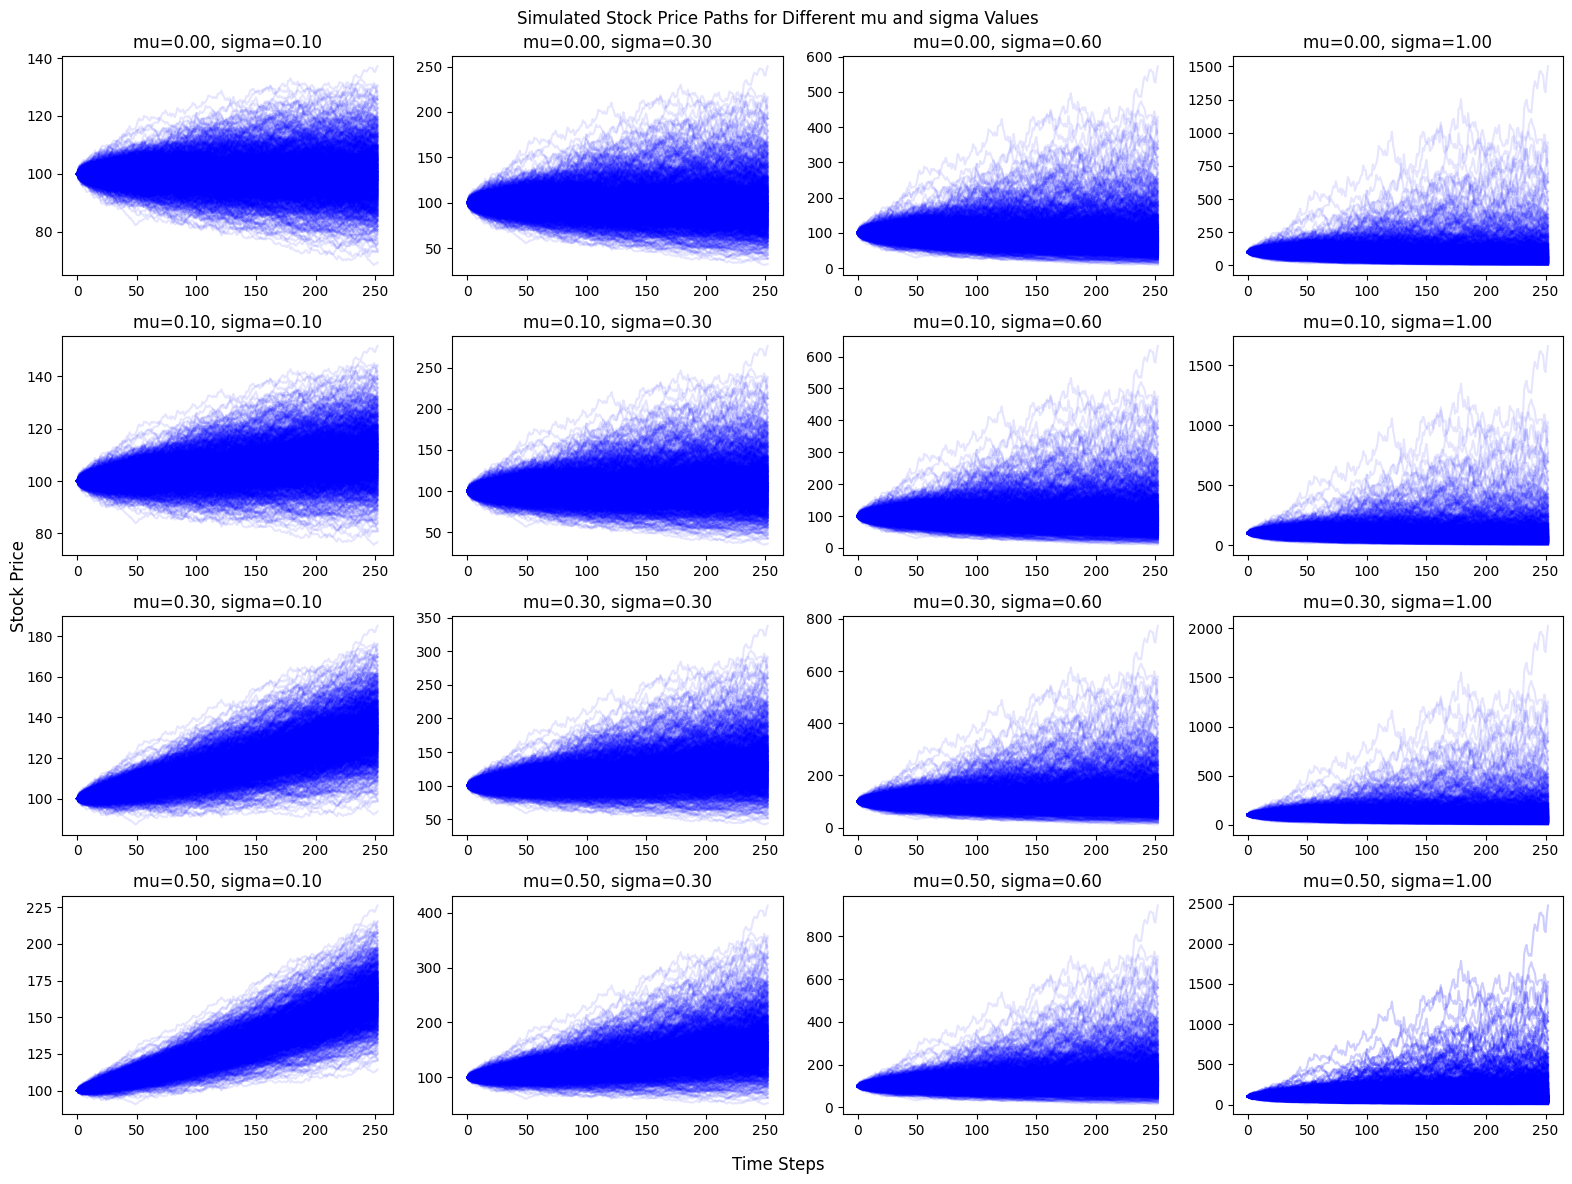

In [4]:
mu_values = [0.0, 0.10, 0.30, 0.50]
sigma_values = [0.10, 0.30, 0.60, 1.00]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, mu in enumerate(mu_values):
    for j, sigma in enumerate(sigma_values):
        #  Building price paths
        prices = np.zeros ((num_paths, N+1))
        prices[:, 0] = s_0 
        for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])
        # Plotting paths
        axes[i, j].plot(prices.T, alpha=0.1, color='blue')
        axes[i,j].set_title(f'mu={mu:.2f}, sigma={sigma:.2f}')

plt.plot(prices.T, alpha=0.1, color='blue')
plt.suptitle('Simulated Stock Price Paths for Different mu and sigma Values')
fig.supxlabel('Time Steps')
fig.supylabel('Stock Price')
plt.tight_layout()
plt.show()